<a href="https://colab.research.google.com/github/2003Himansh/sentiment-analysis/blob/main/Sentimentanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk scikit-learn pandas matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
data = {
    "Review": [
        "This product is amazing, I love it!",
        "Worst product ever, very disappointed.",
        "It is okay, not bad not great.",
        "Excellent quality and fast delivery!",
        "Terrible service, will not buy again.",
        "I am very happy with this purchase.",
        "The item is average.",
        "Very bad experience.",
        "Absolutely fantastic!",
        "Not worth the money."
    ],
    "Sentiment": [
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Negative",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)
df.head()


,Review,Sentiment
0,"This product is amazing, I love it!",Positive
1,"Worst product ever, very disappointed.",Negative
2,"It is okay, not bad not great.",Neutral
3,Excellent quality and fast delivery!,Positive
4,"Terrible service, will not buy again.",Negative


In [ ]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Review"] = df["Review"].apply(clean_text)
df.head()


,Review,Sentiment,Clean_Review
0,"This product is amazing, I love it!",Positive,product amazing love
1,"Worst product ever, very disappointed.",Negative,worst product ever disappointed
2,"It is okay, not bad not great.",Neutral,okay bad great
3,Excellent quality and fast delivery!,Positive,excellent quality fast delivery
4,"Terrible service, will not buy again.",Negative,terrible service buy


In [ ]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Clean_Review"])

y = df["Sentiment"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.3333333333333333

Classification Report:
               precision    recall  f1-score   support

    Negative       0.33      1.00      0.50         1
    Positive       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


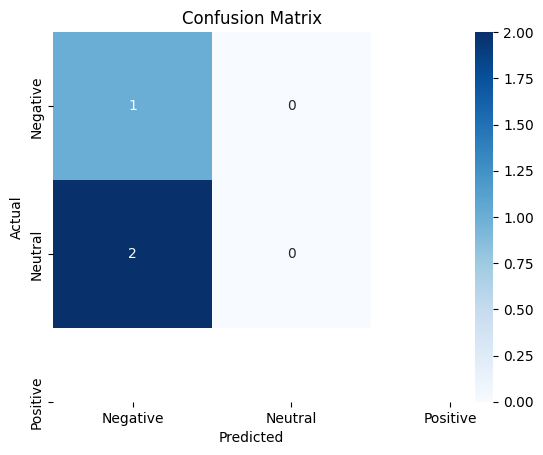

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
